In [1]:
import pandas as pd

df = pd.read_csv("AusOpen-men-2013.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())



Shape: (126, 42)

Columns:
 Index(['Player1', 'Player2', 'Round', 'Result', 'FNL1', 'FNL2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 42 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player1  126 non-null    object 
 1   Player2  126 non-null    object 
 2   Round    126 non-null    int64  
 3   Result   126 non-null    int64  
 4   FNL1     126 non-null    int64  
 5   FNL2     126 non-null    int64  
 6   FSP.1    126 non-null    int64  
 7   FSW.1    126 non-null    int64  
 8   SSP.1    126 non-null    int6

In [2]:
X = df.drop(["Result", "Player1", "Player2", 
             "ST1.1", "ST1.2",
             "ST2.1", "ST2.2",
             "ST3.1", "ST3.2",
             "ST4.1", "ST4.2", 
             "ST5.1", "ST5.2",
             "NPW.1", "NPW.2",
             "TPW.1", "TPW.2",
             "FNL1", "FNL2"
            ], axis=1)
y = df["Result"]

print(df["Result"].value_counts())
print(X.dtypes.value_counts())


Result
1    67
0    59
Name: count, dtype: int64
int64      19
float64     4
Name: count, dtype: int64


In [3]:
X.head()

,Round,FSP.1,FSW.1,SSP.1,SSW.1,ACE.1,DBF.1,WNR.1,UFE.1,BPC.1,...,FSW.2,SSP.2,SSW.2,ACE.2,DBF.2,WNR.2,UFE.2,BPC.2,BPW.2,NPA.2
0,1,61,35,39,18,5,1.0,17,29,1,...,45,32,17,10,0.0,40,30,4,8,8.0
1,1,61,31,39,13,13,1.0,13,1,7,...,23,40,9,1,4.0,1,4,0,0,NaN
2,1,52,53,48,20,8,4.0,37,50,1,...,57,23,15,9,1.0,41,41,4,13,12.0
3,1,53,39,47,24,8,6.0,8,6,6,...,24,50,19,1,8.0,1,8,1,7,NaN
4,1,76,63,24,12,0,4.0,16,35,3,...,59,47,32,17,11.0,59,79,3,5,16.0


In [4]:
# nel Net Points (NPA / NPW) coctituiamo con la media per valutazione del esperto 

X["NPA.1"].fillna(X["NPA.1"].mean(), inplace=True)
X["NPA.2"].fillna(X["NPA.2"].mean(), inplace=True)


/tmp/ipykernel_3009/1750760916.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["NPA.1"].fillna(X["NPA.1"].mean(), inplace=True)
/tmp/ipykernel_3009/1750760916.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [5]:
X["DBF.1"] = X["DBF.1"].fillna(0)
X["DBF.2"] = X["DBF.2"].fillna(0)

In [6]:
print("\nMissing values:")
print(X.isnull().sum())


Missing values:
Round    0
FSP.1    0
FSW.1    0
SSP.1    0
SSW.1    0
ACE.1    0
DBF.1    0
WNR.1    0
UFE.1    0
BPC.1    0
BPW.1    0
NPA.1    0
FSP.2    0
FSW.2    0
SSP.2    0
SSW.2    0
ACE.2    0
DBF.2    0
WNR.2    0
UFE.2    0
BPC.2    0
BPW.2    0
NPA.2    0
dtype: int64


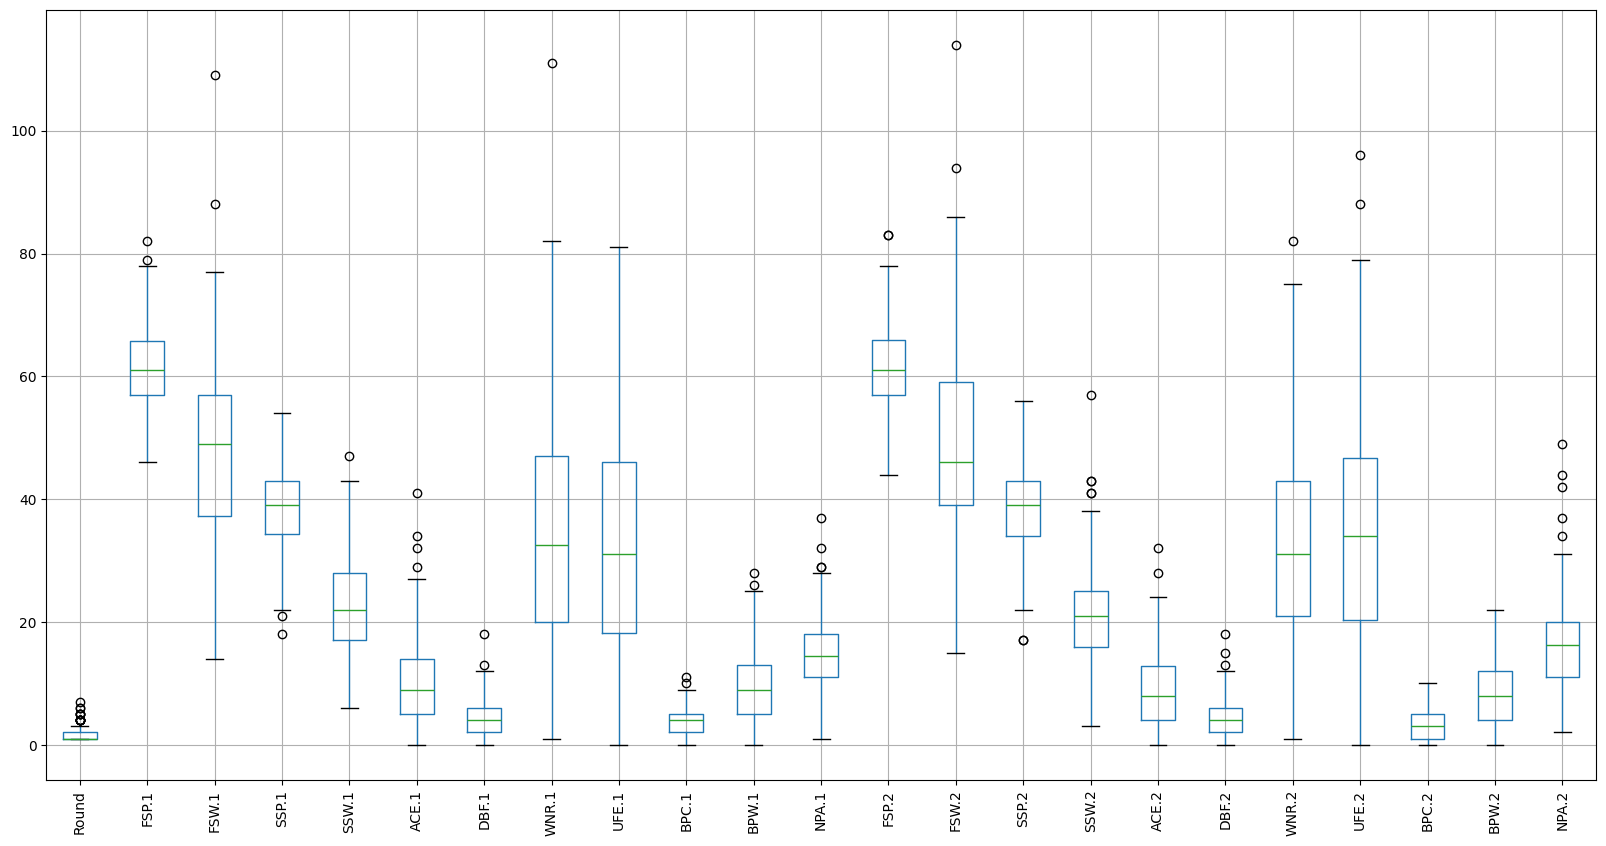

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
X.boxplot()
plt.xticks(rotation=90)
plt.show()


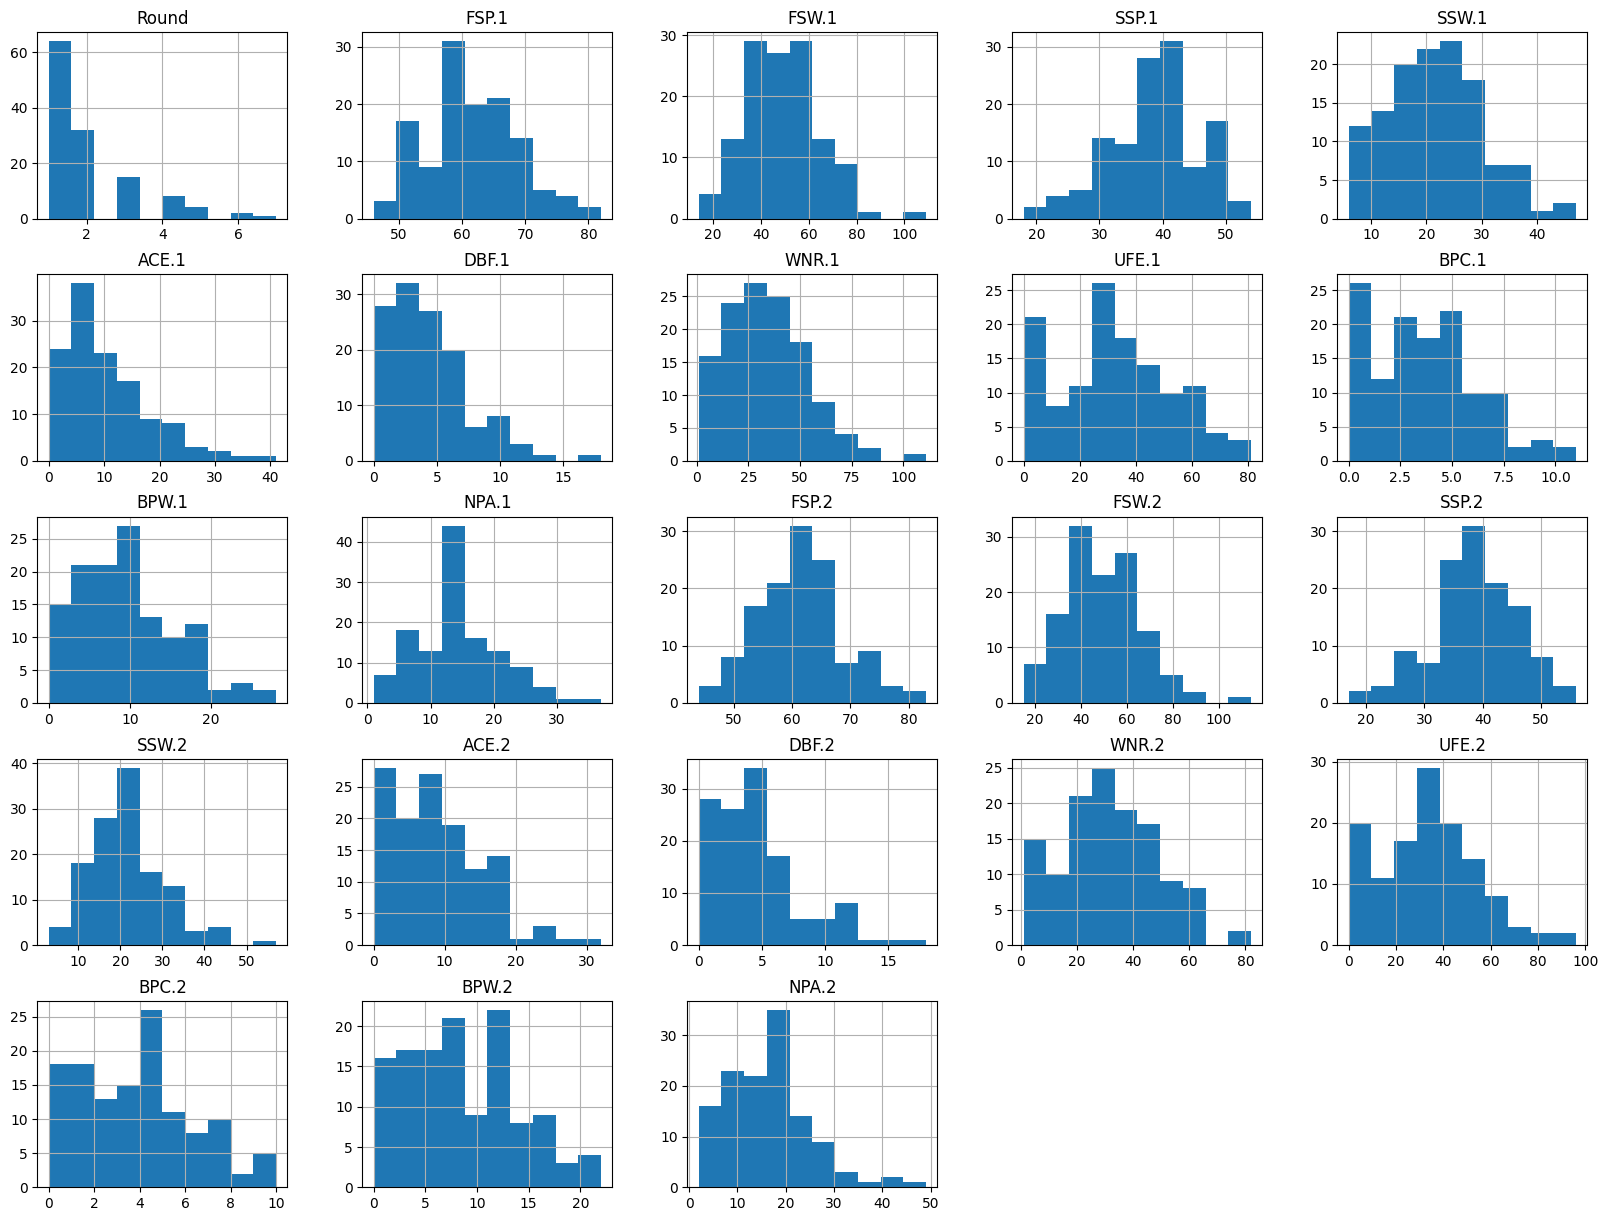

In [8]:
X.hist(figsize=(20,15))
plt.show()


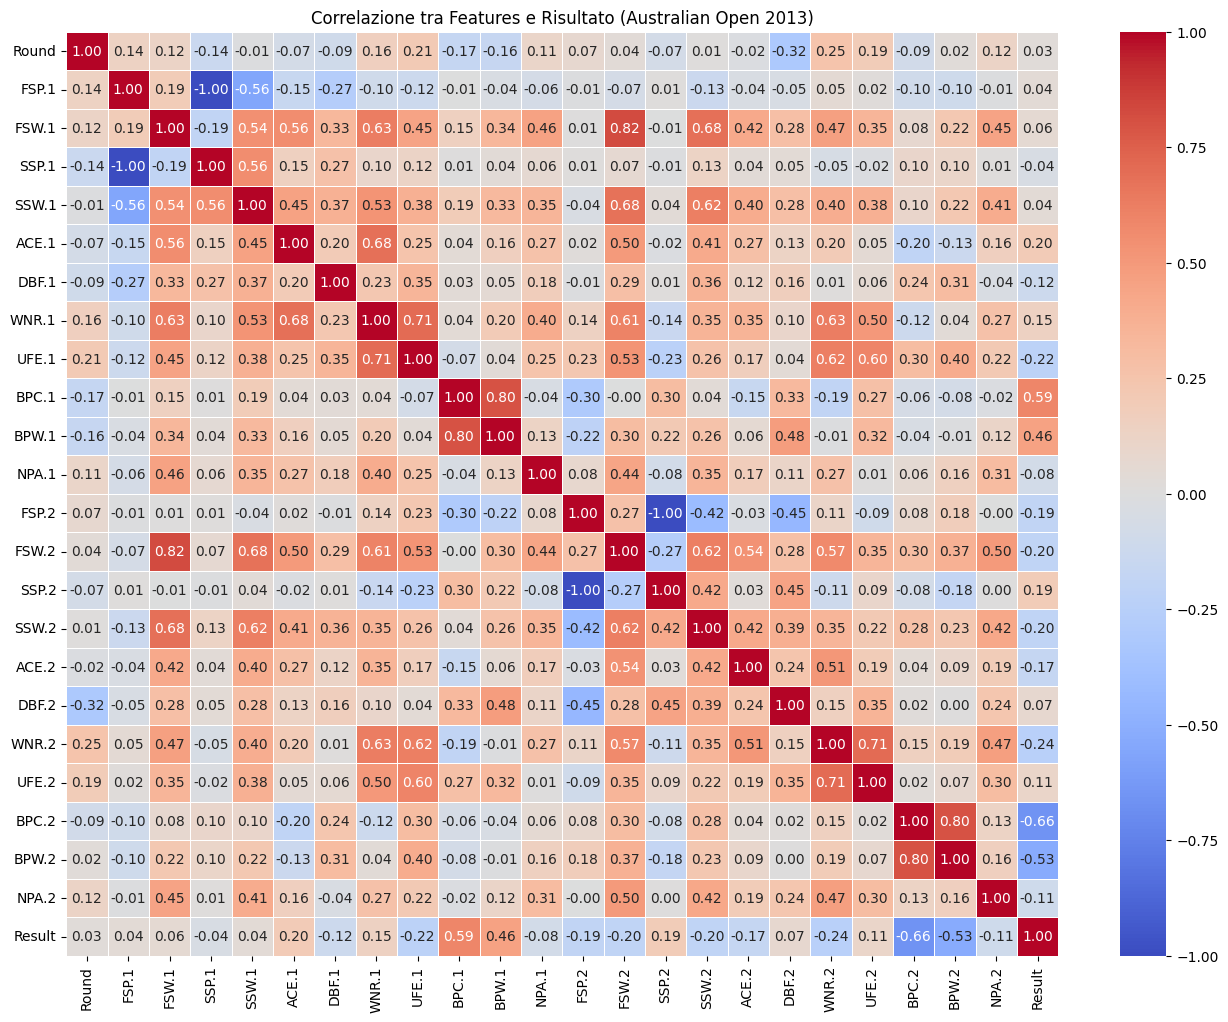

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# CORRELATION HEATMAP
# ==========================

# 1. Uniamo X e y per analizzare anche il target
df_corr = X.copy()
df_corr['Result'] = y

# 2. Matrice di correlazione (Pearson)
corr_matrix = df_corr.corr()

# 3. Heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,       # numeri dentro celle
    fmt=".2f",        # 2 decimali
    cmap="coolwarm",  # rosso positivo / blu negativo
    linewidths=0.5
)

plt.title("Correlazione tra Features e Risultato (Australian Open 2013)")
plt.show()


In [10]:
corr_target = df_corr.corr()['Result'].sort_values(ascending=False)

print(corr_target)


Result    1.000000
BPC.1     0.589931
BPW.1     0.460448
ACE.1     0.202115
SSP.2     0.191211
WNR.1     0.146720
UFE.2     0.107883
DBF.2     0.071940
FSW.1     0.060873
FSP.1     0.040697
SSW.1     0.040433
Round     0.028210
SSP.1    -0.040697
NPA.1    -0.078462
NPA.2    -0.109370
DBF.1    -0.124675
ACE.2    -0.165709
FSP.2    -0.191211
FSW.2    -0.196927
SSW.2    -0.200445
UFE.1    -0.219877
WNR.2    -0.243616
BPW.2    -0.528654
BPC.2    -0.657361
Name: Result, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (100, 23)
Test shape: (26, 23)


In [12]:
# Addestramento Decision Tree

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8461538461538461


In [14]:
# Confusion Matrix

[[10  2]
 [ 2 12]]


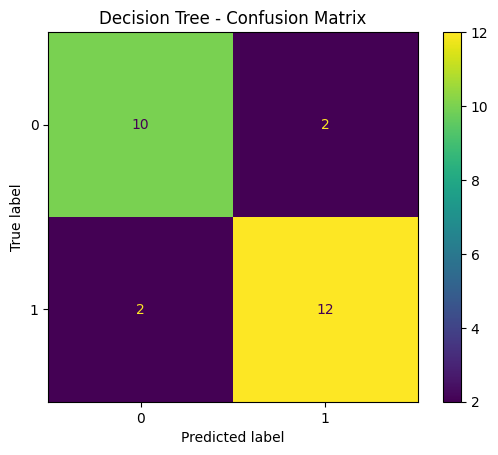

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [16]:
# Classification Report (Precision, Recall, F1)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.86      0.86      0.86        14

    accuracy                           0.85        26
   macro avg       0.85      0.85      0.85        26
weighted avg       0.85      0.85      0.85        26



In [18]:
# ROC Curve + AUC

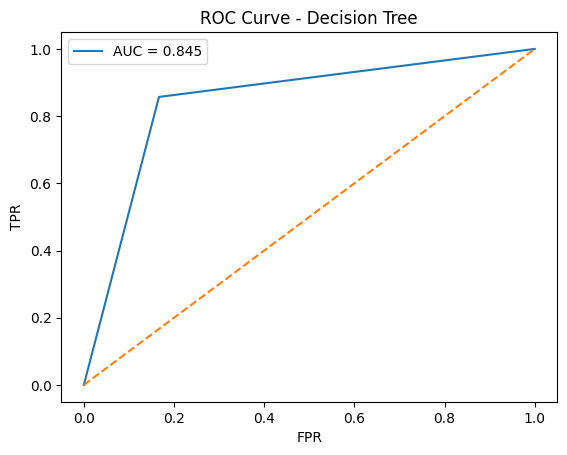

0.8452380952380952


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = tree_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()
print(auc_score)